# Andrea Franco c931897

# Libraries

In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('titanic.csv')
df.shape

(2207, 11)

In [3]:
def uppercase(x):
    return x.upper()

df['new_col'] = df['name'].apply(uppercase)
df['new_col'].head()

0               ABBING, MR. ANTHONY
1         ABBOTT, MR. EUGENE JOSEPH
2       ABBOTT, MR. ROSSMORE EDWARD
3    ABBOTT, MRS. RHODA MARY 'ROSA'
4       ABELSETH, MISS. KAREN MARIE
Name: new_col, dtype: object

In [4]:
for x in df['name'][:3]:
    print(x.upper())

ABBING, MR. ANTHONY
ABBOTT, MR. EUGENE JOSEPH
ABBOTT, MR. ROSSMORE EDWARD


In [5]:
[w.upper() for w in df['name'][:3]]

['ABBING, MR. ANTHONY',
 'ABBOTT, MR. EUGENE JOSEPH',
 'ABBOTT, MR. ROSSMORE EDWARD']

## Concatenating

In [6]:
data_a = {'id': [1, 2, 3, 4, 5],
          'first_name': ['Alex', 'Amy', 'Allen', 'Alice', 'Ayoung'],
          'last_name': ['Anderson', 'Ackerman', 'Ali', 'Aoni', 'Atiches']}
dataframe_a = pd.DataFrame(data_a, columns=['id', 'first_name', 'last_name'])

In [7]:
data_b = {'id': [1, 2, 3, 4, 5],
          'first_name': ['Billy', 'Brian', 'Bran', 'Bryce', 'Betty'],
          'last_name': ['Bonder', 'Black', 'Balwner', 'Brice', 'Btisan']}
dataframe_b = pd.DataFrame(data_b, columns=['id', 'first_name', 'last_name'])

In [8]:
pd.concat([dataframe_a, dataframe_b], axis=0)

,id,first_name,last_name
0,1,Alex,Anderson
1,2,Amy,Ackerman
2,3,Allen,Ali
3,4,Alice,Aoni
4,5,Ayoung,Atiches
0,1,Billy,Bonder
1,2,Brian,Black
2,3,Bran,Balwner
3,4,Bryce,Brice
4,5,Betty,Btisan


In [9]:
df3 = pd.concat([dataframe_a, dataframe_b], axis=1)

## Merging

In [10]:
employee_data = {'employee_id': ['1', '2', '3', '4'],
                 'name': ['Amy Jones', 'Allen Keys', 'Alice Bees', 'Tim Horton']}
dataframe_employees = pd.DataFrame(employee_data, columns=['employee_id', 'name'])

In [11]:
sales_data = {'employee_id': ['3', '4', '5', '6'],
              'total_sales': [234, 351, 124, 98]}
dataframe_sales = pd.DataFrame(sales_data, columns=['employee_id', 'total_sales'])

In [12]:
pd.merge(dataframe_employees, dataframe_sales, on='employee_id', how='right')

,employee_id,name,total_sales
0,3,Alice Bees,234
1,4,Tim Horton,351
2,5,NaN,124
3,6,NaN,98


### When we don't have the same column name for the match key

In [13]:
## Merging
employee_data = {'employee_id': ['1', '2', '3', '4'],
                 'name': ['Amy Jones', 'Allen Keys', 'Alice Bees', 'Tim Horton']}
dataframe_employees = pd.DataFrame(employee_data, columns=['employee_id', 'name'])

sales_data = {'id': ['3', '4', '5', '6'],
              'total_sales': [234, 351, 124, 98]}
dataframe_sales = pd.DataFrame(sales_data, columns=['id', 'total_sales'])


pd.merge(dataframe_employees, dataframe_sales, left_on='employee_id', right_on='id')

,employee_id,name,id,total_sales
0,3,Alice Bees,3,234
1,4,Tim Horton,4,351


In [14]:
dataframe_employees.set_index('employee_id', inplace=True)
dataframe_sales.set_index('id', inplace=True)

In [15]:
dataframe_employees

,name
employee_id,
1,Amy Jones
2,Allen Keys
3,Alice Bees
4,Tim Horton


In [16]:
dataframe_sales

,total_sales
id,
3,234
4,351
5,124
6,98


In [17]:
pd.merge(dataframe_employees, dataframe_sales, left_index= True, right_index= True)

,name,total_sales
3,Alice Bees,234
4,Tim Horton,351


## Normalization

In [18]:
import numpy as np
from sklearn import preprocessing


In [19]:
feature = np.array([[-500.5], [-100.1], [0], [100.1], [900.9]])


In [20]:
minmax_scale = preprocessing.MinMaxScaler(feature_range=(0, 1))

scaled_feature = minmax_scale.fit_transform(feature)
scaled_feature

array([[0.        ],
       [0.28571429],
       [0.35714286],
       [0.42857143],
       [1.        ]])

## Standardization

In [21]:
x = np.array([[-1000.1], [-200.2], [-500.5], [600.6], [9000.9]])

In [22]:
scaler = preprocessing.StandardScaler()

In [23]:
standardized = scaler.fit_transform(x)

In [24]:
standardized

array([[-0.68869611],
       [-0.47519348],
       [-0.55534705],
       [-0.26145063],
       [ 1.98068727]])

In [25]:
np.log(x)

/tmp/ipykernel_9954/1277889159.py:1: RuntimeWarning: invalid value encountered in log
  np.log(x)


array([[       nan],
       [       nan],
       [       nan],
       [6.39792916],
       [9.10507985]])

## Outliers

In [26]:
df = pd.read_csv('Practice_File.csv', usecols=['LotArea', 'SalePrice'])
df.describe()

,LotArea,SalePrice
count,1460.000000,1460.000000
mean,10516.828082,180921.195890
std,9981.264932,79442.502883
min,1300.000000,34900.000000
25%,7553.500000,129975.000000
50%,9478.500000,163000.000000
75%,11601.500000,214000.000000
max,215245.000000,755000.000000


### IQR

In [27]:
q1 = df['SalePrice'].quantile(0.25)
q3 = df['SalePrice'].quantile(0.75)

IQR = q3 - q1
print('q1: ', q1)
print('q3: ', q3)
print('IQR: ', IQR)

q1:  129975.0
q3:  214000.0
IQR:  84025.0


In [28]:
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR
print('lower_limit: ', lower_limit)
print('upper_limit: ', upper_limit)

lower_limit:  3937.5
upper_limit:  340037.5


In [29]:
print((df['SalePrice'] < lower_limit) | (df['SalePrice'] > upper_limit))

0       False
1       False
2       False
3       False
4       False
        ...  
1455    False
1456    False
1457    False
1458    False
1459    False
Name: SalePrice, Length: 1460, dtype: bool


In [30]:
new_df = df[(df['SalePrice'] > lower_limit) & (df['SalePrice'] < upper_limit)]
new_df.shape

(1399, 2)

## Visualization

{'whiskers': [<matplotlib.lines.Line2D at 0x788421036980>,
 'caps': [<matplotlib.lines.Line2D at 0x788421036ec0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7884210366e0>],
 'medians': [<matplotlib.lines.Line2D at 0x788421037400>],
 'fliers': [<matplotlib.lines.Line2D at 0x7884210376a0>],
 'means': []}

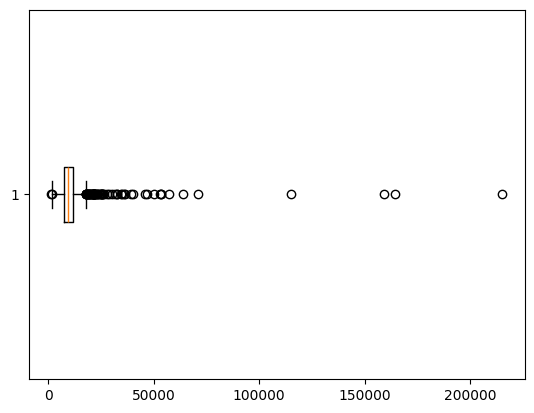

In [31]:
import matplotlib.pyplot as plt
plt.boxplot(df['LotArea'], vert=False)

Text(0, 0.5, 'SalePrice')

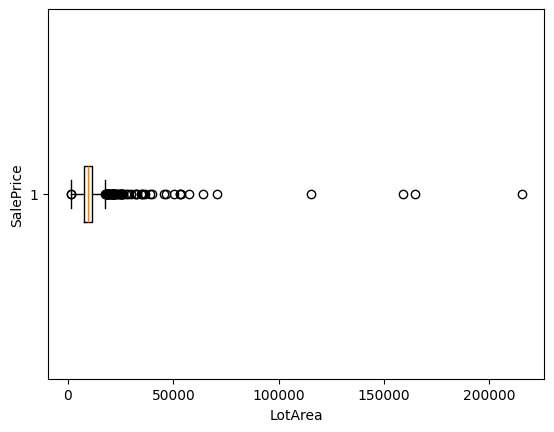

In [32]:
# add axis title
plt.boxplot(df['LotArea'], vert=False)
plt.xlabel('LotArea')
plt.ylabel('SalePrice')

{'whiskers': [<matplotlib.lines.Line2D at 0x78841efa1ab0>,
 'caps': [<matplotlib.lines.Line2D at 0x78841efa1ff0>,
 'boxes': [<matplotlib.lines.Line2D at 0x78841efa1810>],
 'medians': [<matplotlib.lines.Line2D at 0x78841efa2530>],
 'fliers': [<matplotlib.lines.Line2D at 0x78841efa27d0>],
 'means': []}

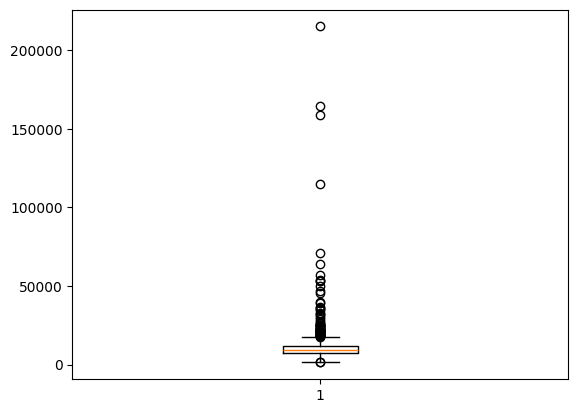

In [33]:
#plot vertical
plt.boxplot(df['LotArea'], vert=True)

## Histograms

<Axes: >

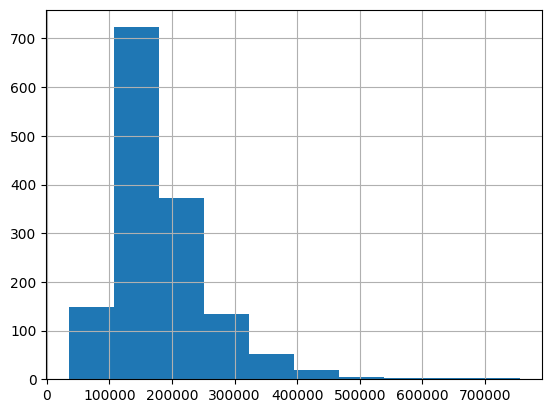

In [34]:
df['SalePrice'].hist()

Text(0, 0.5, 'SalePrice')

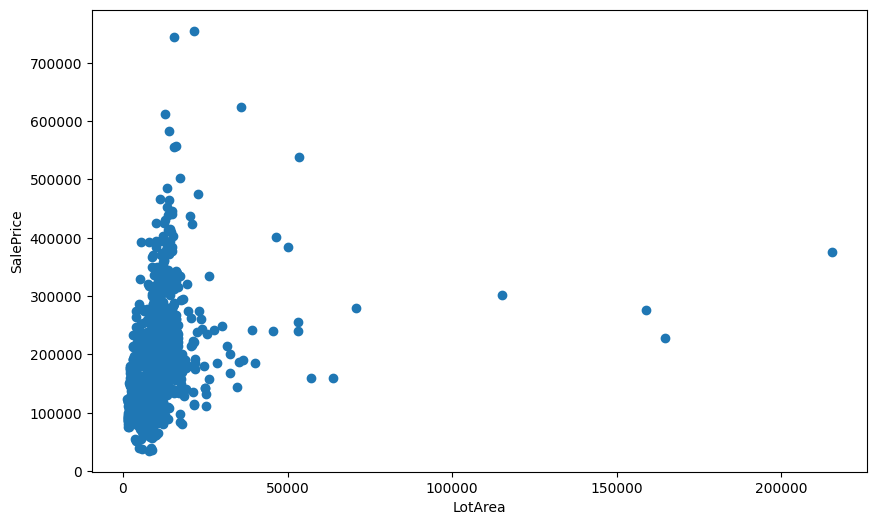

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['LotArea'], df['SalePrice'])
ax.set_xlabel('LotArea')
ax.set_ylabel('SalePrice')

## Outliers treatment

### Quantile-based Flooring and Capping

In [36]:
floor = (df['SalePrice'].quantile(0.01))
cap = (df['SalePrice'].quantile(0.99))
print('Floor: ', floor)
print('Cap: ', cap)

Floor:  61815.97
Cap:  442567.01000000053


In [37]:
df1 = df.copy()
df1['SalePrice'] = np.where(df1['SalePrice']<floor, floor, df1['SalePrice'])
df1['SalePrice'] = np.where(df1['SalePrice']>cap, cap, df1['SalePrice'])

{'whiskers': [<matplotlib.lines.Line2D at 0x78841ed77850>,
 'caps': [<matplotlib.lines.Line2D at 0x78841ed77c70>,
 'boxes': [<matplotlib.lines.Line2D at 0x78841ed775b0>],
 'medians': [<matplotlib.lines.Line2D at 0x78841eda81f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x78841eda8490>],
 'means': []}

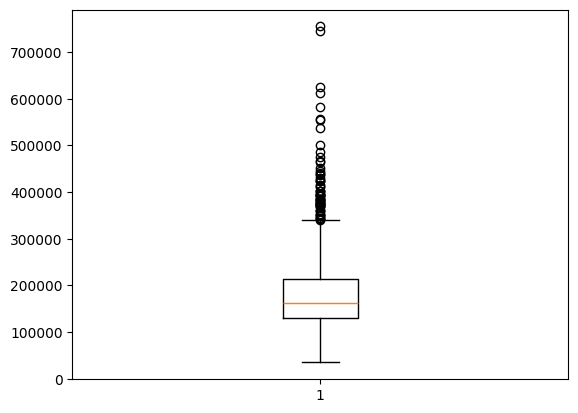

In [38]:
plt.boxplot(df['SalePrice'])

{'whiskers': [<matplotlib.lines.Line2D at 0x78841edf3640>,
 'caps': [<matplotlib.lines.Line2D at 0x78841edf3b80>,
 'boxes': [<matplotlib.lines.Line2D at 0x78841edf33a0>],
 'medians': [<matplotlib.lines.Line2D at 0x78841ec20100>],
 'fliers': [<matplotlib.lines.Line2D at 0x78841ec203a0>],
 'means': []}

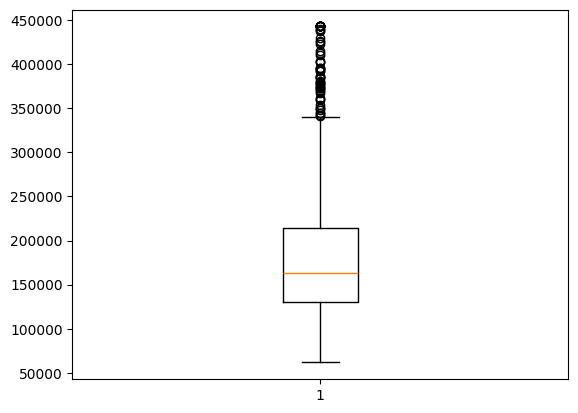

In [40]:
plt.boxplot(df1['SalePrice'])

#### Setting the floor and the cap +- 10%

In [41]:
floor = (df['SalePrice'].quantile(0.09))
cap = (df['SalePrice'].quantile(0.90))
print('Floor: ', floor)
print('Cap: ', cap)
df1 = df.copy()
df1['SalePrice'] = np.where(df1['SalePrice']<floor, floor, df1['SalePrice'])
df1['SalePrice'] = np.where(df1['SalePrice']>cap, cap, df1['SalePrice'])

Floor:  103724.0
Cap:  278000.0


{'whiskers': [<matplotlib.lines.Line2D at 0x78841ec98130>,
 'caps': [<matplotlib.lines.Line2D at 0x78841ec98670>,
 'boxes': [<matplotlib.lines.Line2D at 0x78841ec67e50>],
 'medians': [<matplotlib.lines.Line2D at 0x78841ec98b20>],
 'fliers': [<matplotlib.lines.Line2D at 0x78841ec98dc0>],
 'means': []}

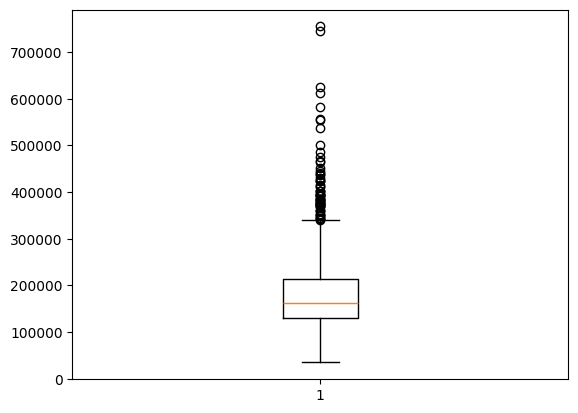

In [42]:
plt.boxplot(df['SalePrice'])

{'whiskers': [<matplotlib.lines.Line2D at 0x78841eb0c310>,
 'caps': [<matplotlib.lines.Line2D at 0x78841eb0c4c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x78841eb0c070>],
 'medians': [<matplotlib.lines.Line2D at 0x78841eb0ca60>],
 'fliers': [<matplotlib.lines.Line2D at 0x78841eb0cd00>],
 'means': []}

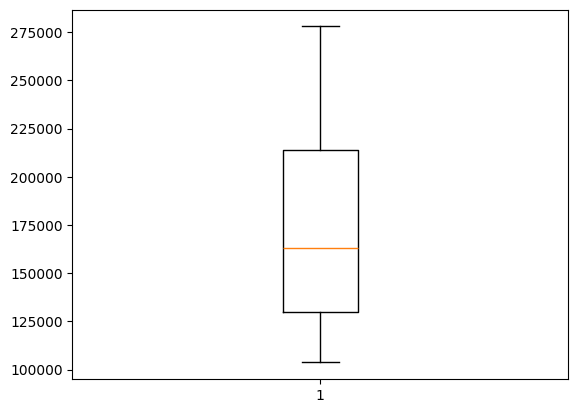

In [43]:
plt.boxplot(df1['SalePrice'])

In [44]:
df2 = df.copy()
print('Number of records in the table: ', df2.shape)
index = df2[(df2['SalePrice']> upper_limit) |
        (df2['SalePrice']< lower_limit)].index
index.shape

Number of records in the table:  (1460, 2)


(61,)

In [45]:
df2.drop(index, inplace=True)
df2.shape

(1399, 2)

#### Log transformation

In [46]:
print(df['SalePrice'].skew().round(2))

1.88


In [48]:
df['log_sale'] = df['SalePrice'].map(lambda i: np.log(i) if i>0 else 0)
print(df['log_sale'].skew().round(2))

0.12


<Axes: >

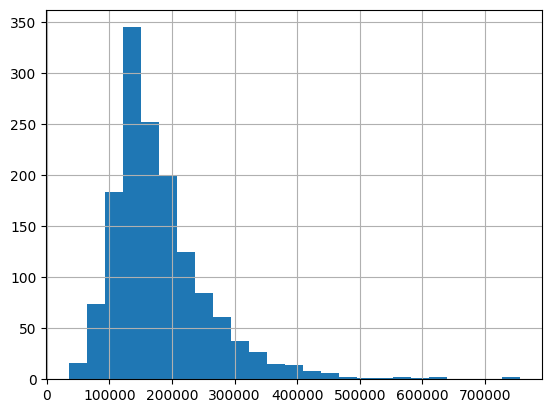

In [49]:
df['SalePrice'].hist(bins=25)

<Axes: >

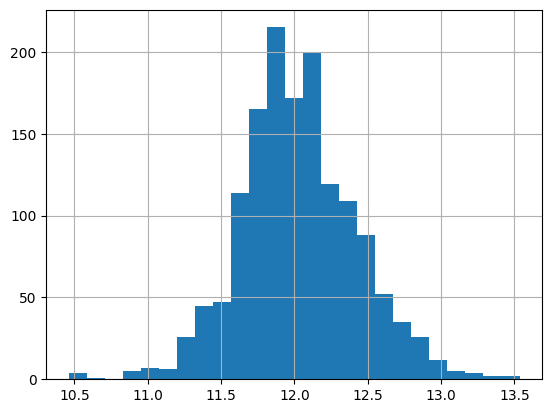

In [51]:
df['log_sale'].hist(bins=25)

# Discretization

## Binarizer

In [52]:
import numpy as np
from sklearn.preprocessing import Binarizer

In [56]:
age = np.array([
    [6],
    [12],
    [18],
    [20],
    [36],
    [65]
])

In [54]:
binarizer = Binarizer(threshold=18)

In [57]:
binarizer.fit_transform(age)

array([[0],
       [0],
       [0],
       [1],
       [1],
       [1]])

## Digitize

In [58]:
age = np.array([[6],
                [12],
                [20],
                [36],
                [65]])

In [59]:
np.digitize(age, bins=[20,30,64])

array([[0],
       [0],
       [1],
       [2],
       [3]])

# Clustering

In [60]:
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [61]:
clusterer = KMeans(3, random_state=0)


In [62]:
features, _ = make_blobs(n_samples=50,
                         n_features=2,
                         centers=3,
                         random_state=1)

In [63]:
clusterer.fit(features)

KMeans(n_clusters=3, random_state=0)

In [64]:
dataframe = pd.DataFrame(features, columns=["feature_1", "feature_2"])

In [65]:
dataframe['group'] = clusterer.predict(features)

In [66]:
dataframe.head()

,feature_1,feature_2,group
0,-9.877554,-3.336145,2
1,-7.287210,-8.353986,0
2,-6.943061,-7.023744,0
3,-7.440167,-8.791959,0
4,-6.641388,-8.075888,0


### KNN imputer

In [67]:
from sklearn.impute import KNNImputer

X = [[1,2, np.nan], [3,4,3], [np.nan,6,5], [8,8,7]]
imputer = KNNImputer(n_neighbors=2)
imputer.fit_transform(X)

array([[1. , 2. , 4. ],
       [3. , 4. , 3. ],
       [5.5, 6. , 5. ],
       [8. , 8. , 7. ]])

### Simple Imputer

In [68]:
from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
imp_mean.fit([[7,2,3],[4,np.nan, 6], [10,5,9]])

SimpleImputer()

In [69]:
X = [[np.nan, 2, 3], [4, np.nan, 6], [10, np.nan, 9]]
print(imp_mean.transform(X))

[[ 7.   2.   3. ]
 [ 4.   3.5  6. ]
 [10.   3.5  9. ]]


In [ ]:
from sklearn import preprocessing
lb = preprocessing.Label

## Nominal Variables

In [71]:
df = pd.DataFrame({'X':['a','b','a'], 'Y':['B','A','C'],'Z':[1,2,3]})
df

,X,Y,Z
0,a,B,1
1,b,A,2
2,a,C,3


In [73]:
pd.get_dummies(df, prefix=['colX','colY'], dtype=int)

,Z,colX_a,colX_b,colY_A,colY_B,colY_C
0,1,1,0,0,1,0
1,2,0,1,1,0,0
2,3,1,0,0,0,1


## Ordinal variables

In [74]:
dataframe = pd.DataFrame({"Score": ["Low",
                                    "Low",
                                    "Medium",
                                    "Medium",
                                    "High",
                                    "Barely More Than Medium"]})

In [77]:
scale_mapper = {"Low":1,
                "Medium":2,
                "Barely More Than Medium":3,
                "High":4}

In [78]:
dataframe["Score"].replace(scale_mapper)

/tmp/ipykernel_9954/1505037610.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe["Score"].replace(scale_mapper)


0    1
1    1
2    2
3    2
4    4
5    3
Name: Score, dtype: int64